# 04 Report Figures

**Objective**: Generate publication-ready charts for final presentation/report.

**Output Location**: `figs/report_charts/`

**Charts to Generate**:
1. Average daily profits before and after surcharge
2. Average profits per customer/hour before and after surcharge
3. Number of Dine-in customers before and after surcharge
4. Total profits from all items (drink + merchandise)
5. Average daily use of reusable cups before and after surcharge
6. Most ordered items by reusable cup customers (after surcharge)
7. Hot drinks vs cold drinks ordered by reusable cup customers
8. Average reusable cup users on weekend vs weekday


In [1]:
# Setup
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="husl")

# Paths
DATA_DIR = Path("../data/processed")
OUTPUT_DIR = Path("../figs/report_charts")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Load data
df = pd.read_csv(DATA_DIR / "transactions.csv")
df['date'] = pd.to_datetime(df['date'])
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Key date
SURCHARGE_START = pd.to_datetime("2023-11-01")

print("="*80)
print("REPORT CHARTS GENERATION")
print("="*80)
print(f"Data loaded: {len(df):,} transactions")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Output directory: {OUTPUT_DIR}")
print("="*80)


REPORT CHARTS GENERATION
Data loaded: 30,525 transactions
Date range: 2022-01-01 to 2024-12-31
Output directory: ../figs/report_charts


## Chart 1: Average Daily Profits Before and After Surcharge



CHART 1: AVERAGE DAILY PROFITS BEFORE AND AFTER SURCHARGE
Pre-surcharge:  $86.24/day (669 days)
Post-surcharge: $119.22/day (427 days)
Change: $+32.97/day (+38.2%)
✓ Saved: ../figs/report_charts/01_daily_profits_comparison.png


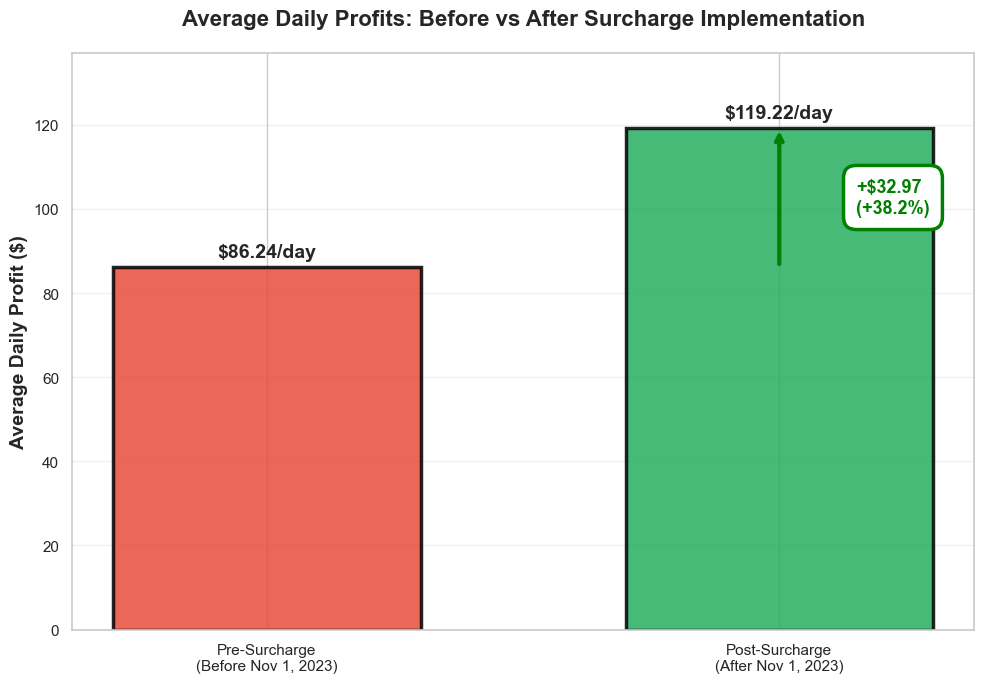

In [2]:
print("\n" + "="*80)
print("CHART 1: AVERAGE DAILY PROFITS BEFORE AND AFTER SURCHARGE")
print("="*80)

# Split data by surcharge period
df_pre = df[df['date'] < SURCHARGE_START]
df_post = df[df['date'] >= SURCHARGE_START]

# Calculate daily profits
days_pre = (df_pre['date'].max() - df_pre['date'].min()).days + 1
days_post = (df_post['date'].max() - df_post['date'].min()).days + 1

daily_profit_pre = df_pre['gross_margin'].sum() / days_pre
daily_profit_post = df_post['gross_margin'].sum() / days_post

change = daily_profit_post - daily_profit_pre
pct_change = (change / daily_profit_pre) * 100

print(f"Pre-surcharge:  ${daily_profit_pre:.2f}/day ({days_pre} days)")
print(f"Post-surcharge: ${daily_profit_post:.2f}/day ({days_post} days)")
print(f"Change: ${change:+.2f}/day ({pct_change:+.1f}%)")

# Create chart
fig, ax = plt.subplots(figsize=(10, 7))

periods = ['Pre-Surcharge\n(Before Nov 1, 2023)', 'Post-Surcharge\n(After Nov 1, 2023)']
profits = [daily_profit_pre, daily_profit_post]
colors = ['#E74C3C', '#27AE60']

bars = ax.bar(periods, profits, color=colors, alpha=0.85, 
              edgecolor='black', linewidth=2.5, width=0.6)

# Add value labels
for bar, val in zip(bars, profits):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 1.5,
           f'${val:.2f}/day', ha='center', va='bottom',
           fontweight='bold', fontsize=14)

# Add change arrow and label
ax.annotate('', xy=(1, daily_profit_post), xytext=(1, daily_profit_pre),
           arrowprops=dict(arrowstyle='->', lw=3, color='green'))
ax.text(1.15, (daily_profit_pre + daily_profit_post) / 2,
       f'+${change:.2f}\n({pct_change:+.1f}%)',
       fontweight='bold', fontsize=13, color='green',
       bbox=dict(boxstyle='round,pad=0.7', facecolor='white', 
                edgecolor='green', linewidth=2.5),
       va='center')

ax.set_ylabel('Average Daily Profit ($)', fontweight='bold', fontsize=14)
ax.set_title('Average Daily Profits: Before vs After Surcharge Implementation',
            fontweight='bold', fontsize=16, pad=20)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, max(profits) * 1.15)

plt.tight_layout()
save_path = OUTPUT_DIR / "01_daily_profits_comparison.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"✓ Saved: {save_path}")
plt.show()


## Chart 2: Average Profits Per Customer/Hour Before and After Surcharge



CHART 2: AVERAGE PROFITS PER CUSTOMER/HOUR BEFORE AND AFTER SURCHARGE
Pre-surcharge avg per hour:  $3.44
Post-surcharge avg per hour: $3.69
✓ Saved: ../figs/report_charts/02_hourly_profits_comparison.png


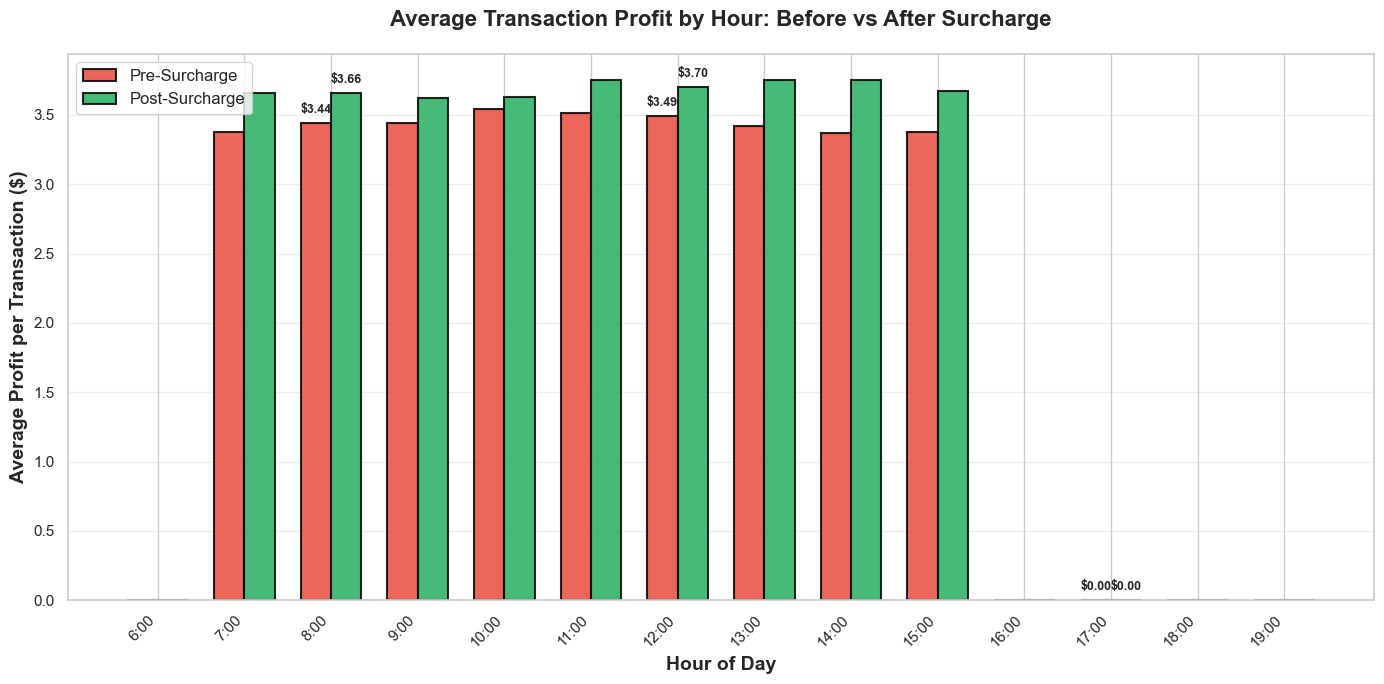

In [3]:
print("\n" + "="*80)
print("CHART 2: AVERAGE PROFITS PER CUSTOMER/HOUR BEFORE AND AFTER SURCHARGE")
print("="*80)

# Calculate hourly profits
hourly_profit_pre = df_pre.groupby('hour')['gross_margin'].mean()
hourly_profit_post = df_post.groupby('hour')['gross_margin'].mean()

print(f"Pre-surcharge avg per hour:  ${hourly_profit_pre.mean():.2f}")
print(f"Post-surcharge avg per hour: ${hourly_profit_post.mean():.2f}")

# Create chart
fig, ax = plt.subplots(figsize=(14, 7))

hours = np.arange(6, 20)  # Cafe hours
width = 0.35

# Filter to cafe hours
pre_data = [hourly_profit_pre.get(h, 0) for h in hours]
post_data = [hourly_profit_post.get(h, 0) for h in hours]

bars1 = ax.bar(hours - width/2, pre_data, width, label='Pre-Surcharge',
              color='#E74C3C', alpha=0.85, edgecolor='black', linewidth=1.5)
bars2 = ax.bar(hours + width/2, post_data, width, label='Post-Surcharge',
              color='#27AE60', alpha=0.85, edgecolor='black', linewidth=1.5)

# Add value labels on bars (for select hours)
for i, h in enumerate([8, 12, 17]):  # Peak hours
    if h in hours:
        idx = list(hours).index(h)
        height1 = bars1[idx].get_height()
        height2 = bars2[idx].get_height()
        ax.text(bars1[idx].get_x() + bars1[idx].get_width()/2., height1 + 0.05,
               f'${height1:.2f}', ha='center', va='bottom',
               fontweight='bold', fontsize=9)
        ax.text(bars2[idx].get_x() + bars2[idx].get_width()/2., height2 + 0.05,
               f'${height2:.2f}', ha='center', va='bottom',
               fontweight='bold', fontsize=9)

ax.set_xlabel('Hour of Day', fontweight='bold', fontsize=14)
ax.set_ylabel('Average Profit per Transaction ($)', fontweight='bold', fontsize=14)
ax.set_title('Average Transaction Profit by Hour: Before vs After Surcharge',
            fontweight='bold', fontsize=16, pad=20)
ax.set_xticks(hours)
ax.set_xticklabels([f'{h}:00' for h in hours], rotation=45, ha='right')
ax.legend(fontsize=12, loc='upper left')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
save_path = OUTPUT_DIR / "02_hourly_profits_comparison.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"✓ Saved: {save_path}")
plt.show()


## Chart 3: Number of Dine-in Customers Before and After Surcharge



CHART 3: NUMBER OF DINE-IN CUSTOMERS BEFORE AND AFTER SURCHARGE
Pre-surcharge:  1,773 unique dine-in customers
Post-surcharge: 1,772 unique dine-in customers
Change: -1 (-0.1%)
✓ Saved: ../figs/report_charts/03_dinein_customers_comparison.png


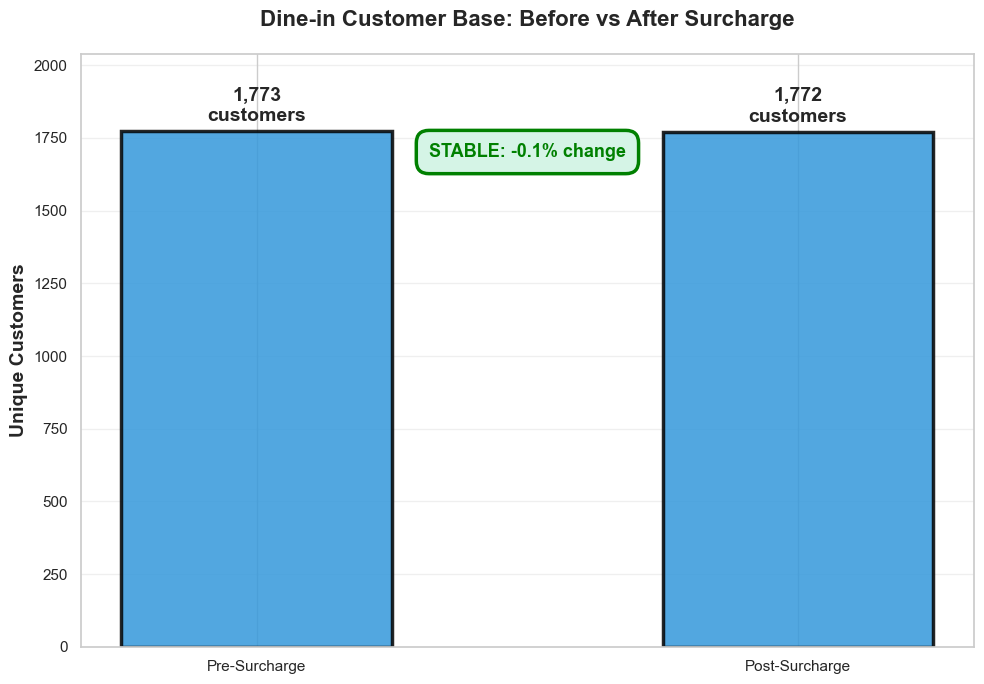

In [4]:
print("\n" + "="*80)
print("CHART 3: NUMBER OF DINE-IN CUSTOMERS BEFORE AND AFTER SURCHARGE")
print("="*80)

# Count unique dine-in customers
dinein_customers_pre = df_pre[df_pre['transaction_type']=='Dine-in']['customer_id'].nunique()
dinein_customers_post = df_post[df_post['transaction_type']=='Dine-in']['customer_id'].nunique()

change_customers = dinein_customers_post - dinein_customers_pre
pct_change_customers = (change_customers / dinein_customers_pre) * 100

print(f"Pre-surcharge:  {dinein_customers_pre:,} unique dine-in customers")
print(f"Post-surcharge: {dinein_customers_post:,} unique dine-in customers")
print(f"Change: {change_customers:+,} ({pct_change_customers:+.1f}%)")

# Create chart
fig, ax = plt.subplots(figsize=(10, 7))

periods = ['Pre-Surcharge', 'Post-Surcharge']
customers = [dinein_customers_pre, dinein_customers_post]
colors = ['#3498DB', '#3498DB']

bars = ax.bar(periods, customers, color=colors, alpha=0.85,
              edgecolor='black', linewidth=2.5, width=0.5)

# Add value labels
for bar, val in zip(bars, customers):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 20,
           f'{val:,}\ncustomers', ha='center', va='bottom',
           fontweight='bold', fontsize=14)

# Add change annotation
if abs(pct_change_customers) > 0.5:
    color = 'green' if change_customers > 0 else 'red'
    ax.annotate('', xy=(1, dinein_customers_post), xytext=(1, dinein_customers_pre),
               arrowprops=dict(arrowstyle='->', lw=3, color=color))
    ax.text(1.15, (dinein_customers_pre + dinein_customers_post) / 2,
           f'{change_customers:+,}\n({pct_change_customers:+.1f}%)',
           fontweight='bold', fontsize=12, color=color,
           bbox=dict(boxstyle='round,pad=0.7', facecolor='white',
                    edgecolor=color, linewidth=2.5),
           va='center')
else:
    # Nearly stable
    ax.text(0.5, max(customers) * 0.95,
           f'STABLE: {pct_change_customers:+.1f}% change',
           fontweight='bold', fontsize=13, color='green',
           bbox=dict(boxstyle='round,pad=0.7', facecolor='#D5F4E6',
                    edgecolor='green', linewidth=2.5),
           ha='center')

ax.set_ylabel('Unique Customers', fontweight='bold', fontsize=14)
ax.set_title('Dine-in Customer Base: Before vs After Surcharge',
            fontweight='bold', fontsize=16, pad=20)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, max(customers) * 1.15)

plt.tight_layout()
save_path = OUTPUT_DIR / "03_dinein_customers_comparison.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"✓ Saved: {save_path}")
plt.show()


## Chart 4: Total Profits from All Items (Drink + Merchandise)



CHART 4: TOTAL PROFITS FROM ALL ITEMS (DRINK + MERCHANDISE)
Total profit (all items): $108,603.65
  Drink: $90,159.65 (83.0%) @ 72.9% margin
  Merchandise: $18,444.00 (17.0%) @ 59.9% margin
✓ Saved: ../figs/report_charts/04_total_profits_by_type.png


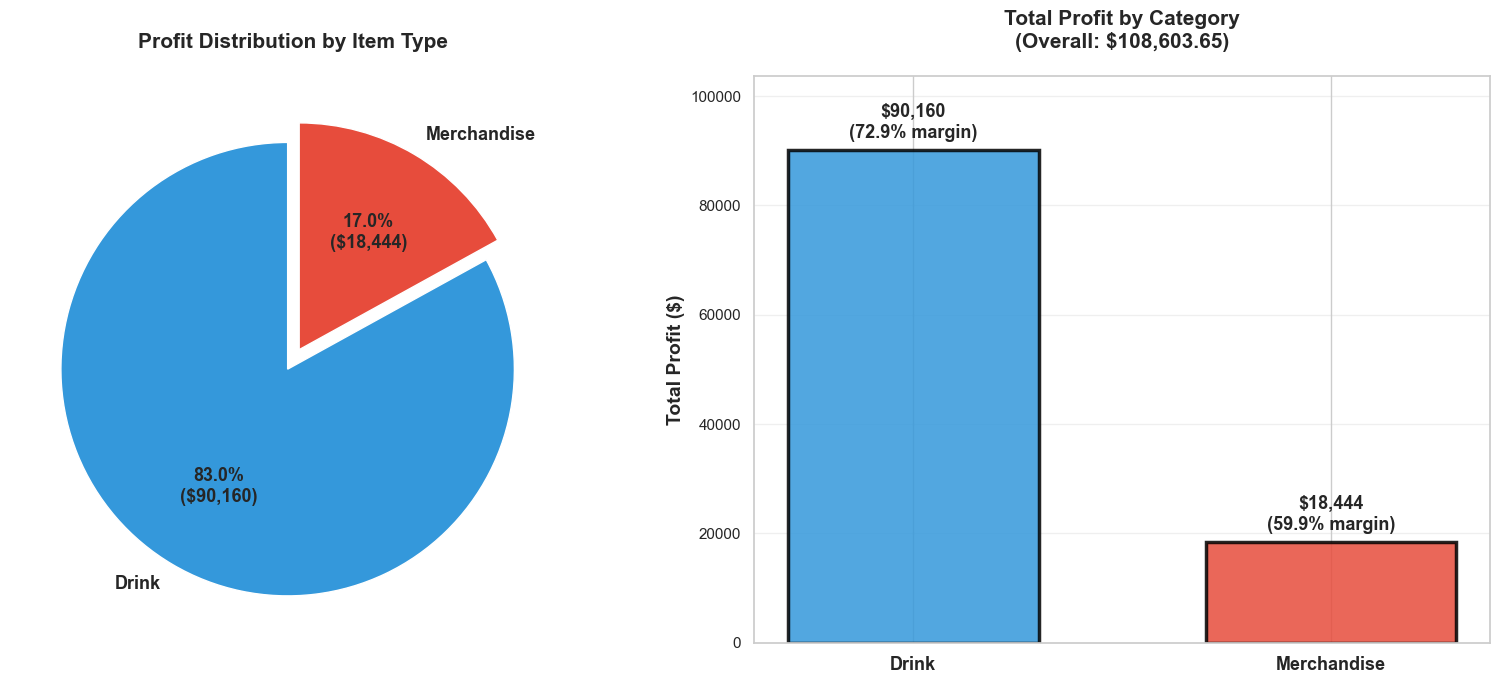

In [5]:
print("\n" + "="*80)
print("CHART 4: TOTAL PROFITS FROM ALL ITEMS (DRINK + MERCHANDISE)")
print("="*80)

# Calculate profits by item type
type_profits = df.groupby('item_type').agg({
    'gross_margin': 'sum',
    'price': 'sum'
}).round(2)
type_profits['margin_pct'] = (type_profits['gross_margin'] / type_profits['price'] * 100).round(1)

total_profit = df['gross_margin'].sum()

print(f"Total profit (all items): ${total_profit:,.2f}")
for item_type in type_profits.index:
    profit = type_profits.loc[item_type, 'gross_margin']
    pct = (profit / total_profit * 100)
    margin = type_profits.loc[item_type, 'margin_pct']
    print(f"  {item_type}: ${profit:,.2f} ({pct:.1f}%) @ {margin:.1f}% margin")

# Create chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Chart 1: Pie chart of profit distribution
colors_pie = ['#3498DB', '#E74C3C']
explode = (0.05, 0.05)
wedges, texts, autotexts = ax1.pie(type_profits['gross_margin'],
                                     labels=type_profits.index,
                                     autopct=lambda pct: f'{pct:.1f}%\n(${pct*total_profit/100:,.0f})',
                                     colors=colors_pie,
                                     explode=explode,
                                     startangle=90,
                                     textprops={'fontweight': 'bold', 'fontsize': 13})
ax1.set_title('Profit Distribution by Item Type',
             fontweight='bold', fontsize=15, pad=20)

# Chart 2: Bar chart with values
x_pos = np.arange(len(type_profits))
bars = ax2.bar(x_pos, type_profits['gross_margin'],
              color=colors_pie, alpha=0.85,
              edgecolor='black', linewidth=2.5, width=0.6)

# Add value labels
for bar, idx in zip(bars, type_profits.index):
    height = bar.get_height()
    profit = type_profits.loc[idx, 'gross_margin']
    margin = type_profits.loc[idx, 'margin_pct']
    ax2.text(bar.get_x() + bar.get_width()/2., height + 1500,
            f'${profit:,.0f}\n({margin:.1f}% margin)',
            ha='center', va='bottom',
            fontweight='bold', fontsize=13)

ax2.set_xticks(x_pos)
ax2.set_xticklabels(type_profits.index, fontweight='bold', fontsize=13)
ax2.set_ylabel('Total Profit ($)', fontweight='bold', fontsize=14)
ax2.set_title(f'Total Profit by Category\n(Overall: ${total_profit:,.2f})',
             fontweight='bold', fontsize=15, pad=20)
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_ylim(0, type_profits['gross_margin'].max() * 1.15)

plt.tight_layout()
save_path = OUTPUT_DIR / "04_total_profits_by_type.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"✓ Saved: {save_path}")
plt.show()


## Chart 5: Average Daily Use of Reusable Cups Before and After Surcharge



CHART 5: AVERAGE DAILY USE OF REUSABLE CUPS BEFORE AND AFTER SURCHARGE
Pre-surcharge:  9.6 reusable cups/day (40.1% adoption)
Post-surcharge: 14.3 reusable cups/day (48.7% adoption)
Change: +4.7 cups/day (+49.2%)
✓ Saved: ../figs/report_charts/05_reusable_cups_usage.png


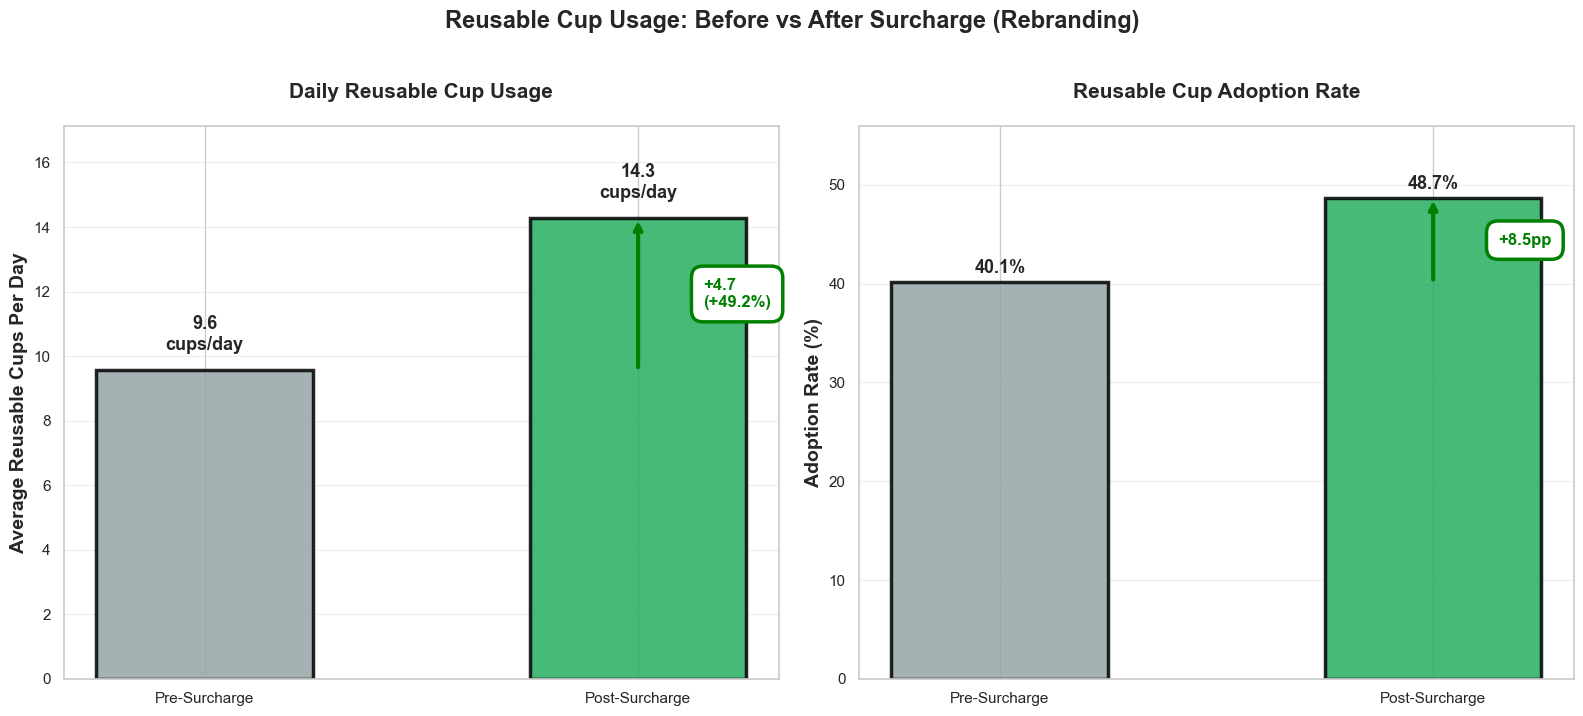

In [6]:
print("\n" + "="*80)
print("CHART 5: AVERAGE DAILY USE OF REUSABLE CUPS BEFORE AND AFTER SURCHARGE")
print("="*80)

# Filter to drinks only
drinks_df = df[df['own_cup'].notna()].copy()
drinks_pre = drinks_df[drinks_df['date'] < SURCHARGE_START]
drinks_post = drinks_df[drinks_df['date'] >= SURCHARGE_START]

# Calculate daily reusable cup usage
days_drinks_pre = (drinks_pre['date'].max() - drinks_pre['date'].min()).days + 1
days_drinks_post = (drinks_post['date'].max() - drinks_post['date'].min()).days + 1

reusable_pre = drinks_pre['own_cup'].sum()
reusable_post = drinks_post['own_cup'].sum()

daily_reusable_pre = reusable_pre / days_drinks_pre
daily_reusable_post = reusable_post / days_drinks_post

change_daily = daily_reusable_post - daily_reusable_pre
pct_change_daily = (change_daily / daily_reusable_pre) * 100

# Adoption rates
adoption_pre = (reusable_pre / len(drinks_pre)) * 100
adoption_post = (reusable_post / len(drinks_post)) * 100

print(f"Pre-surcharge:  {daily_reusable_pre:.1f} reusable cups/day ({adoption_pre:.1f}% adoption)")
print(f"Post-surcharge: {daily_reusable_post:.1f} reusable cups/day ({adoption_post:.1f}% adoption)")
print(f"Change: {change_daily:+.1f} cups/day ({pct_change_daily:+.1f}%)")

# Create chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Chart 1: Daily usage
periods = ['Pre-Surcharge', 'Post-Surcharge']
daily_usage = [daily_reusable_pre, daily_reusable_post]
colors = ['#95A5A6', '#27AE60']

bars1 = ax1.bar(periods, daily_usage, color=colors, alpha=0.85,
               edgecolor='black', linewidth=2.5, width=0.5)

for bar, val in zip(bars1, daily_usage):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f'{val:.1f}\ncups/day', ha='center', va='bottom',
            fontweight='bold', fontsize=13)

# Add change arrow
ax1.annotate('', xy=(1, daily_reusable_post), xytext=(1, daily_reusable_pre),
            arrowprops=dict(arrowstyle='->', lw=3, color='green'))
ax1.text(1.15, (daily_reusable_pre + daily_reusable_post) / 2,
        f'+{change_daily:.1f}\n({pct_change_daily:+.1f}%)',
        fontweight='bold', fontsize=12, color='green',
        bbox=dict(boxstyle='round,pad=0.7', facecolor='white',
                 edgecolor='green', linewidth=2.5),
        va='center')

ax1.set_ylabel('Average Reusable Cups Per Day', fontweight='bold', fontsize=14)
ax1.set_title('Daily Reusable Cup Usage', fontweight='bold', fontsize=15, pad=20)
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_ylim(0, max(daily_usage) * 1.2)

# Chart 2: Adoption rate
adoption_rates = [adoption_pre, adoption_post]
bars2 = ax2.bar(periods, adoption_rates, color=colors, alpha=0.85,
               edgecolor='black', linewidth=2.5, width=0.5)

for bar, val in zip(bars2, adoption_rates):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f'{val:.1f}%', ha='center', va='bottom',
            fontweight='bold', fontsize=13)

# Add change annotation
adoption_change = adoption_post - adoption_pre
ax2.annotate('', xy=(1, adoption_post), xytext=(1, adoption_pre),
            arrowprops=dict(arrowstyle='->', lw=3, color='green'))
ax2.text(1.15, (adoption_pre + adoption_post) / 2,
        f'+{adoption_change:.1f}pp',
        fontweight='bold', fontsize=12, color='green',
        bbox=dict(boxstyle='round,pad=0.7', facecolor='white',
                 edgecolor='green', linewidth=2.5),
        va='center')

ax2.set_ylabel('Adoption Rate (%)', fontweight='bold', fontsize=14)
ax2.set_title('Reusable Cup Adoption Rate', fontweight='bold', fontsize=15, pad=20)
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_ylim(0, max(adoption_rates) * 1.15)

plt.suptitle('Reusable Cup Usage: Before vs After Surcharge (Rebranding)',
            fontsize=17, fontweight='bold', y=1.02)
plt.tight_layout()
save_path = OUTPUT_DIR / "05_reusable_cups_usage.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"✓ Saved: {save_path}")
plt.show()


## Chart 6: Most Ordered Items by Reusable Cup Customers (After Surcharge)



CHART 6: MOST ORDERED ITEMS BY REUSABLE CUP CUSTOMERS (AFTER SURCHARGE)
Total reusable cup orders (post-surcharge): 6,098

Top 10 items:
   1. Green Tea                  663 orders ( 10.9%)
   2. Latte                      567 orders (  9.3%)
   3. Americano                  552 orders (  9.1%)
   4. Chai Latte                 543 orders (  8.9%)
   5. Cappuccino                 536 orders (  8.8%)
   6. Mocha                      505 orders (  8.3%)
   7. Matcha Latte               433 orders (  7.1%)
   8. Iced Matcha Latte          431 orders (  7.1%)
   9. Hot Chocolate              398 orders (  6.5%)
  10. Iced Coffee                353 orders (  5.8%)
✓ Saved: ../figs/report_charts/06_reusable_cup_top_items.png


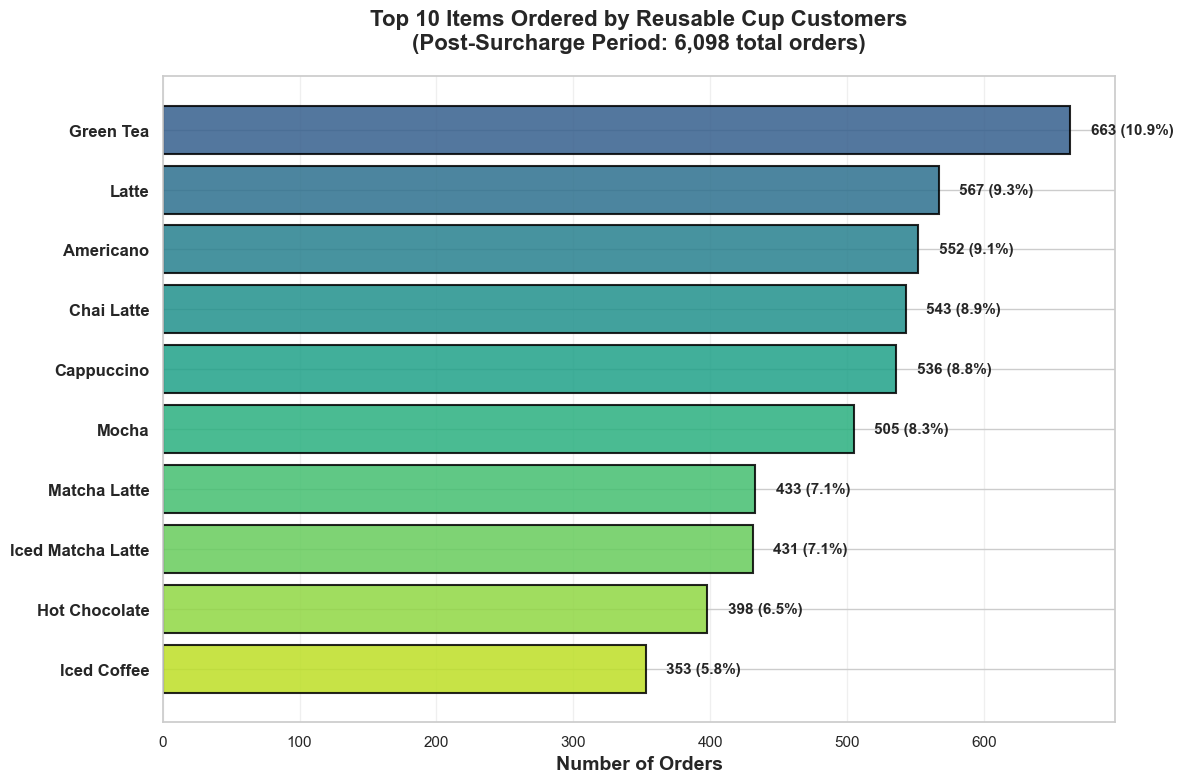

In [7]:
print("\n" + "="*80)
print("CHART 6: MOST ORDERED ITEMS BY REUSABLE CUP CUSTOMERS (AFTER SURCHARGE)")
print("="*80)

# Filter to post-surcharge, drinks only, own cup users
reusable_cup_orders = drinks_post[drinks_post['own_cup'] == True]

# Count orders by item
item_counts = reusable_cup_orders['item_name'].value_counts().head(10)
total_reusable_orders = len(reusable_cup_orders)

print(f"Total reusable cup orders (post-surcharge): {total_reusable_orders:,}")
print(f"\nTop 10 items:")
for i, (item, count) in enumerate(item_counts.items(), 1):
    pct = (count / total_reusable_orders) * 100
    print(f"  {i:2d}. {item:25s} {count:4,} orders ({pct:5.1f}%)")

# Create chart
fig, ax = plt.subplots(figsize=(12, 8))

y_pos = np.arange(len(item_counts))
colors_gradient = plt.cm.viridis(np.linspace(0.3, 0.9, len(item_counts)))

bars = ax.barh(y_pos, item_counts.values, color=colors_gradient,
              alpha=0.85, edgecolor='black', linewidth=1.5)

# Add value labels
for i, (bar, val) in enumerate(zip(bars, item_counts.values)):
    width = bar.get_width()
    pct = (val / total_reusable_orders) * 100
    ax.text(width + 15, bar.get_y() + bar.get_height()/2.,
           f'{val:,} ({pct:.1f}%)', va='center',
           fontweight='bold', fontsize=11)

ax.set_yticks(y_pos)
ax.set_yticklabels(item_counts.index, fontsize=12, fontweight='bold')
ax.invert_yaxis()
ax.set_xlabel('Number of Orders', fontweight='bold', fontsize=14)
ax.set_title(f'Top 10 Items Ordered by Reusable Cup Customers\n(Post-Surcharge Period: {total_reusable_orders:,} total orders)',
            fontweight='bold', fontsize=16, pad=20)
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
save_path = OUTPUT_DIR / "06_reusable_cup_top_items.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"✓ Saved: {save_path}")
plt.show()


## Chart 7: Hot Drinks vs Cold Drinks Ordered by Reusable Cup Customers



CHART 7: HOT VS COLD DRINKS ORDERED BY REUSABLE CUP CUSTOMERS
Total drinks with reusable cups: 12,500
  Hot: 9,901 (79.2%)
  Cold: 2,599 (20.8%)
✓ Saved: ../figs/report_charts/07_reusable_cups_hot_vs_cold.png


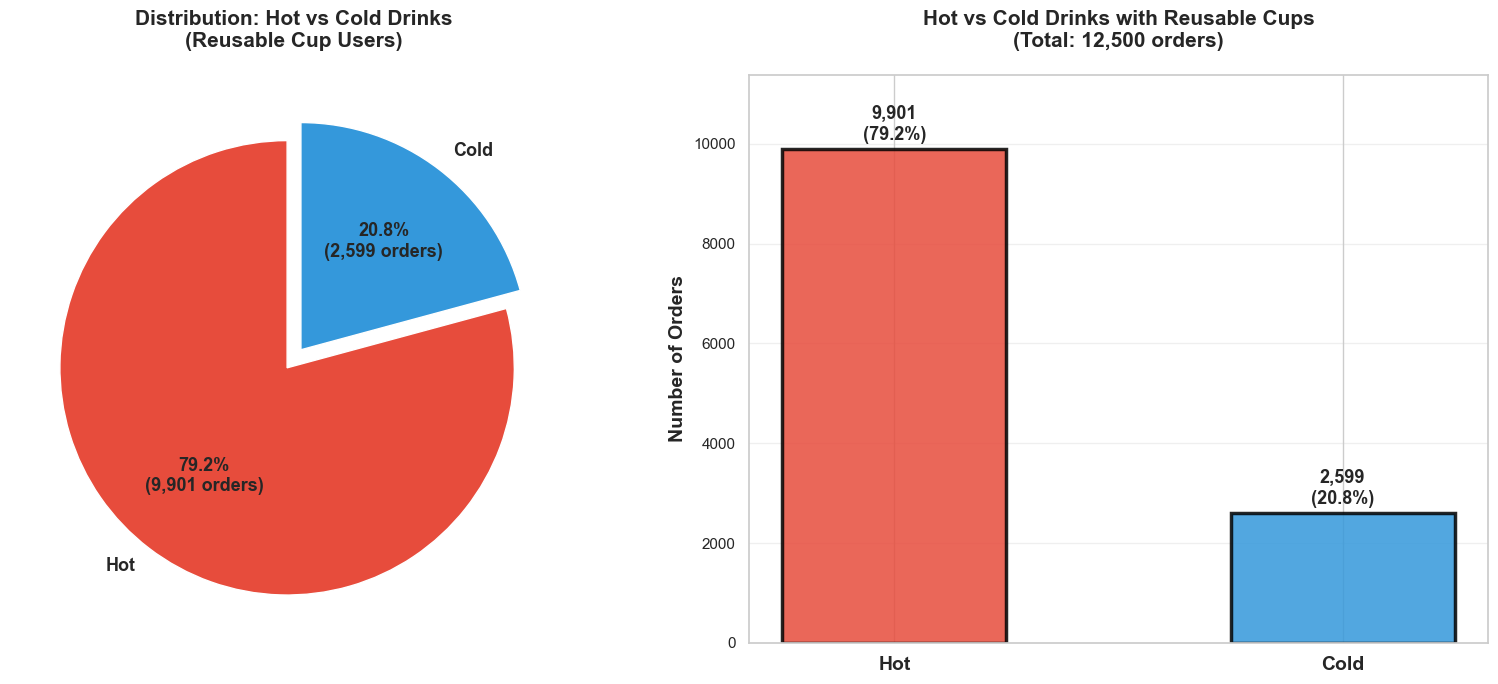

In [8]:
print("\n" + "="*80)
print("CHART 7: HOT VS COLD DRINKS ORDERED BY REUSABLE CUP CUSTOMERS")
print("="*80)

# Filter to reusable cup users
reusable_drinks = drinks_df[drinks_df['own_cup'] == True].copy()

# Count by temperature
temp_counts = reusable_drinks['drink_temperature'].value_counts()
total_reusable_drinks = len(reusable_drinks)

print(f"Total drinks with reusable cups: {total_reusable_drinks:,}")
for temp in temp_counts.index:
    count = temp_counts[temp]
    pct = (count / total_reusable_drinks) * 100
    print(f"  {temp}: {count:,} ({pct:.1f}%)")

# Create chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Chart 1: Pie chart
colors_temp = {'Hot': '#E74C3C', 'Cold': '#3498DB'}
colors = [colors_temp.get(temp, '#95A5A6') for temp in temp_counts.index]
explode = (0.05, 0.05)

wedges, texts, autotexts = ax1.pie(temp_counts.values,
                                     labels=temp_counts.index,
                                     autopct=lambda pct: f'{pct:.1f}%\n({int(pct*total_reusable_drinks/100):,} orders)',
                                     colors=colors,
                                     explode=explode,
                                     startangle=90,
                                     textprops={'fontweight': 'bold', 'fontsize': 13})
ax1.set_title('Distribution: Hot vs Cold Drinks\n(Reusable Cup Users)',
             fontweight='bold', fontsize=15, pad=20)

# Chart 2: Bar chart
x_pos = np.arange(len(temp_counts))
bars = ax2.bar(x_pos, temp_counts.values,
              color=colors, alpha=0.85,
              edgecolor='black', linewidth=2.5, width=0.5)

# Add value labels
for bar, temp in zip(bars, temp_counts.index):
    height = bar.get_height()
    count = temp_counts[temp]
    pct = (count / total_reusable_drinks) * 100
    ax2.text(bar.get_x() + bar.get_width()/2., height + 100,
            f'{count:,}\n({pct:.1f}%)', ha='center', va='bottom',
            fontweight='bold', fontsize=13)

ax2.set_xticks(x_pos)
ax2.set_xticklabels(temp_counts.index, fontweight='bold', fontsize=14)
ax2.set_ylabel('Number of Orders', fontweight='bold', fontsize=14)
ax2.set_title(f'Hot vs Cold Drinks with Reusable Cups\n(Total: {total_reusable_drinks:,} orders)',
             fontweight='bold', fontsize=15, pad=20)
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_ylim(0, temp_counts.max() * 1.15)

plt.tight_layout()
save_path = OUTPUT_DIR / "07_reusable_cups_hot_vs_cold.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"✓ Saved: {save_path}")
plt.show()


## Chart 8: Average Reusable Cup Users on Weekend vs Weekday



CHART 8: AVERAGE REUSABLE CUP USERS ON WEEKEND VS WEEKDAY
Weekday average: 13.3 reusable cups/day (711 weekdays)
Weekend average: 10.6 reusable cups/day (285 weekend days)
Difference: -2.7 cups/day (-20.1%)
✓ Saved: ../figs/report_charts/08_reusable_cups_weekday_weekend.png


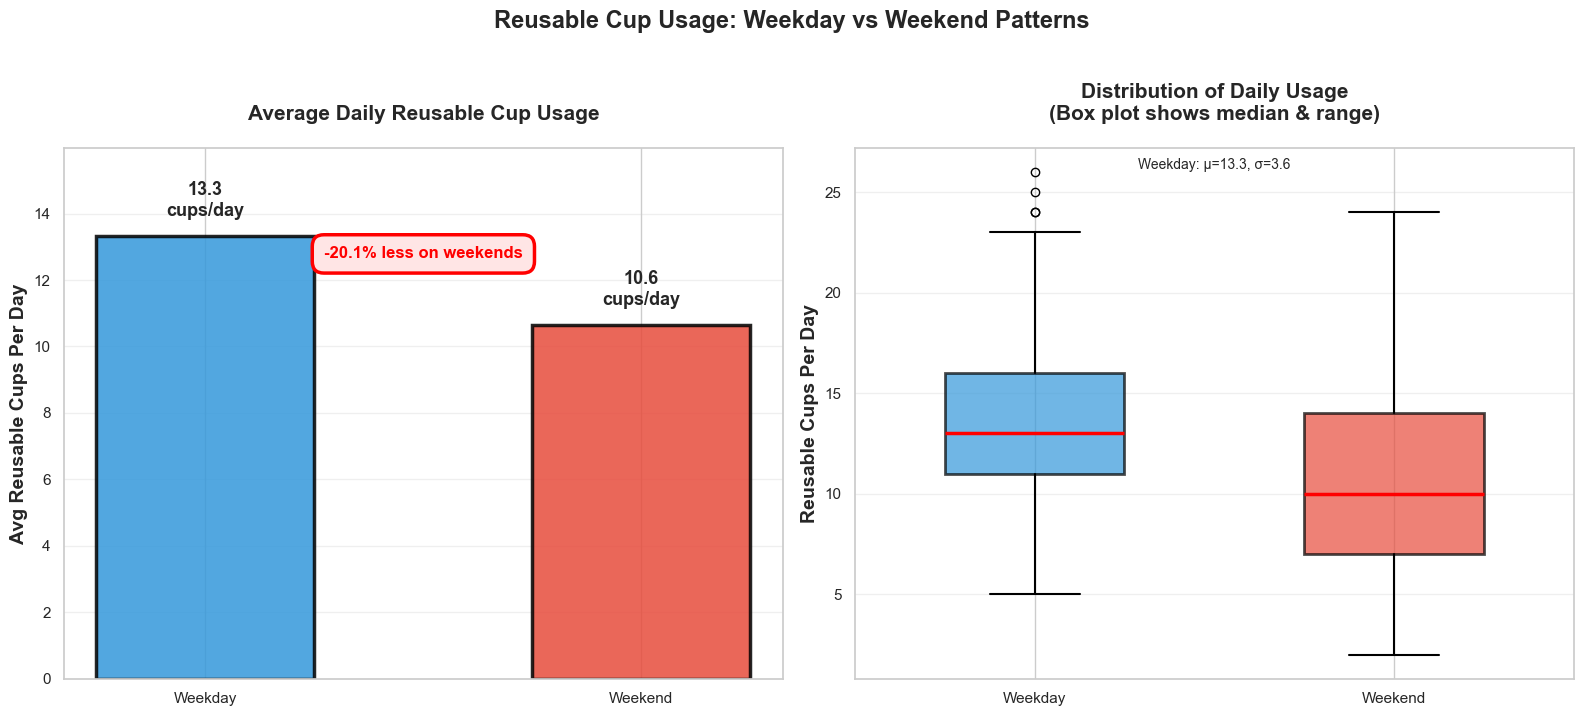

In [9]:
print("\n" + "="*80)
print("CHART 8: AVERAGE REUSABLE CUP USERS ON WEEKEND VS WEEKDAY")
print("="*80)

# Filter to drinks with reusable cups
reusable_drinks = drinks_df[drinks_df['own_cup'] == True].copy()

# Group by date and is_weekend
daily_reusable = reusable_drinks.groupby(['date', 'is_weekend']).size().reset_index(name='count')

# Calculate averages
weekday_avg = daily_reusable[daily_reusable['is_weekend'] == False]['count'].mean()
weekend_avg = daily_reusable[daily_reusable['is_weekend'] == True]['count'].mean()

# Count unique dates
weekdays = daily_reusable[daily_reusable['is_weekend'] == False]['date'].nunique()
weekends = daily_reusable[daily_reusable['is_weekend'] == True]['date'].nunique()

difference = weekend_avg - weekday_avg
pct_diff = (difference / weekday_avg) * 100

print(f"Weekday average: {weekday_avg:.1f} reusable cups/day ({weekdays} weekdays)")
print(f"Weekend average: {weekend_avg:.1f} reusable cups/day ({weekends} weekend days)")
print(f"Difference: {difference:+.1f} cups/day ({pct_diff:+.1f}%)")

# Create chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Chart 1: Bar comparison
day_types = ['Weekday', 'Weekend']
averages = [weekday_avg, weekend_avg]
colors = ['#3498DB', '#E74C3C']

bars1 = ax1.bar(day_types, averages, color=colors, alpha=0.85,
               edgecolor='black', linewidth=2.5, width=0.5)

# Add value labels
for bar, val in zip(bars1, averages):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f'{val:.1f}\ncups/day', ha='center', va='bottom',
            fontweight='bold', fontsize=13)

# Add comparison annotation
if abs(pct_diff) > 5:
    if difference > 0:
        ax1.annotate('', xy=(1, weekend_avg), xytext=(1, weekday_avg),
                    arrowprops=dict(arrowstyle='->', lw=3, color='green'))
        ax1.text(1.15, (weekday_avg + weekend_avg) / 2,
                f'+{difference:.1f}\n({pct_diff:+.1f}%)',
                fontweight='bold', fontsize=12, color='green',
                bbox=dict(boxstyle='round,pad=0.7', facecolor='white',
                         edgecolor='green', linewidth=2.5),
                va='center')
    else:
        ax1.text(0.5, max(averages) * 0.95,
                f'{pct_diff:.1f}% less on weekends',
                fontweight='bold', fontsize=12, color='red',
                bbox=dict(boxstyle='round,pad=0.7', facecolor='#FFE5E5',
                         edgecolor='red', linewidth=2.5),
                ha='center')
else:
    ax1.text(0.5, max(averages) * 0.95,
            'Similar usage on weekdays and weekends',
            fontweight='bold', fontsize=12, color='green',
            bbox=dict(boxstyle='round,pad=0.7', facecolor='#D5F4E6',
                     edgecolor='green', linewidth=2.5),
            ha='center')

ax1.set_ylabel('Avg Reusable Cups Per Day', fontweight='bold', fontsize=14)
ax1.set_title('Average Daily Reusable Cup Usage', fontweight='bold', fontsize=15, pad=20)
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_ylim(0, max(averages) * 1.2)

# Chart 2: Distribution over days (box plot style)
weekday_data = daily_reusable[daily_reusable['is_weekend'] == False]['count']
weekend_data = daily_reusable[daily_reusable['is_weekend'] == True]['count']

bp = ax2.boxplot([weekday_data, weekend_data],
                 labels=day_types,
                 patch_artist=True,
                 widths=0.5,
                 boxprops=dict(facecolor='lightblue', alpha=0.7, linewidth=2),
                 medianprops=dict(color='red', linewidth=2.5),
                 whiskerprops=dict(linewidth=1.5),
                 capprops=dict(linewidth=1.5))

# Color the boxes
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax2.set_ylabel('Reusable Cups Per Day', fontweight='bold', fontsize=14)
ax2.set_title('Distribution of Daily Usage\n(Box plot shows median & range)',
             fontweight='bold', fontsize=15, pad=20)
ax2.grid(True, alpha=0.3, axis='y')

# Add summary stats
ax2.text(0.5, 0.98, f'Weekday: μ={weekday_avg:.1f}, σ={weekday_data.std():.1f}',
        transform=ax2.transAxes, ha='center', va='top',
        fontsize=10, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle('Reusable Cup Usage: Weekday vs Weekend Patterns',
            fontsize=17, fontweight='bold', y=1.02)
plt.tight_layout()
save_path = OUTPUT_DIR / "08_reusable_cups_weekday_weekend.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"✓ Saved: {save_path}")
plt.show()


In [10]:
print("\n" + "="*80)
print("REPORT CHARTS GENERATION COMPLETE!")
print("="*80)
print(f"\nAll 8 charts have been saved to: {OUTPUT_DIR}")
print("\nGenerated charts:")
for i, chart_name in enumerate([
    "01_daily_profits_comparison.png",
    "02_hourly_profits_comparison.png",
    "03_dinein_customers_comparison.png",
    "04_total_profits_by_type.png",
    "05_reusable_cups_usage.png",
    "06_reusable_cup_top_items.png",
    "07_reusable_cups_hot_vs_cold.png",
    "08_reusable_cups_weekday_weekend.png"
], 1):
    print(f"  {i}. {chart_name}")

print(f"\n✓ Ready for presentation/report!")
print("="*80)



REPORT CHARTS GENERATION COMPLETE!

All 8 charts have been saved to: ../figs/report_charts

Generated charts:
  1. 01_daily_profits_comparison.png
  2. 02_hourly_profits_comparison.png
  3. 03_dinein_customers_comparison.png
  4. 04_total_profits_by_type.png
  5. 05_reusable_cups_usage.png
  6. 06_reusable_cup_top_items.png
  7. 07_reusable_cups_hot_vs_cold.png
  8. 08_reusable_cups_weekday_weekend.png

✓ Ready for presentation/report!
